# Mestrado em Inteligência Artificial 25/26

# Practical 3 — Dynamic Programming (Gridworld)
## Policy Improvement & Policy Iteration — **Solutions Notebook**

**Goal:** You already know how to compute $(V^\pi)$ (policy evaluation).  
Today we add **policy improvement** and combine both into **policy iteration**.

**What you will implement in class:** only the **TODO** inside `policy_improvement()`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Dict, Tuple, Optional, List

np.set_printoptions(precision=3, suppress=True)

In [2]:
ACTIONS = ["U", "D", "L", "R"]

ACTION_TO_DELTA = {
    "U": (-1, 0),
    "D": ( 1, 0),
    "L": ( 0,-1),
    "R": ( 0, 1),
}

ARROW = {"U":"↑", "D":"↓", "L":"←", "R":"→", "·":"·"}

@dataclass(frozen=True)
class Gridworld:
    n_rows: int = 4
    n_cols: int = 4
    terminal_states: Tuple[Tuple[int,int], ...] = ((0,0), (3,3))
    step_reward: float = -1.0

    def states(self) -> List[Tuple[int,int]]:
        return [(r,c) for r in range(self.n_rows) for c in range(self.n_cols)]

    def is_terminal(self, s: Tuple[int,int]) -> bool:
        return s in self.terminal_states

    def step(self, s: Tuple[int,int], a: str) -> Tuple[Tuple[int,int], float, bool]:
        """Deterministic transitions. If action would leave the grid -> stay in place."""
        if self.is_terminal(s):
            return s, 0.0, True

        dr, dc = ACTION_TO_DELTA[a]
        nr, nc = s[0] + dr, s[1] + dc

        # bump into wall => stay
        if nr < 0 or nr >= self.n_rows or nc < 0 or nc >= self.n_cols:
            ns = s
        else:
            ns = (nr, nc)

        r = self.step_reward
        done = self.is_terminal(ns)
        return ns, r, done

env = Gridworld()
env.states()[:5], env.terminal_states

([(0, 0), (0, 1), (0, 2), (0, 3), (1, 0)], ((0, 0), (3, 3)))

## Utils

In [3]:
def zeros_V(env: Gridworld) -> np.ndarray:
    return np.zeros((env.n_rows, env.n_cols), dtype=float)

def plot_grid(env: Gridworld, V: np.ndarray, policy: Optional[Dict[Tuple[int,int], str]] = None, title: str = "", ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,6))
    ax.set_title(title)

    ax.set_xlim(0, env.n_cols)
    ax.set_ylim(0, env.n_rows)
    ax.set_xticks(np.arange(env.n_cols+1))
    ax.set_yticks(np.arange(env.n_rows+1))
    ax.grid(True)
    ax.invert_yaxis()
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    for (r,c) in env.terminal_states:
        rect = plt.Rectangle((c, r), 1, 1, fill=True, alpha=0.15)
        ax.add_patch(rect)

    for r in range(env.n_rows):
        for c in range(env.n_cols):
            s = (r,c)
            ax.text(c+0.5, r+0.45, f"{V[r,c]:.2f}", ha="center", va="center", fontsize=12)
            if policy is not None:
                a = policy.get(s, "·") if policy.get(s, None) is not None else "·"
                ax.text(c+0.5, r+0.78, ARROW.get(a, "·"), ha="center", va="center", fontsize=18)

    if ax is None:
        plt.show()

### Policy

In [4]:
def uniform_random_policy(env: Gridworld) -> Dict[Tuple[int,int], Dict[str, float]]:
    """π(a|s) = 1/4 for non-terminal states."""
    pi = {}
    for s in env.states():
        if env.is_terminal(s):
            pi[s] = {a: 0.0 for a in ACTIONS}
        else:
            pi[s] = {a: 1.0/len(ACTIONS) for a in ACTIONS}
    return pi

pi0 = uniform_random_policy(env)
pi0[(1,1)]

{'U': 0.25, 'D': 0.25, 'L': 0.25, 'R': 0.25}

## Policy Evaluation (given a fixed policy)

We compute $(V^\pi)$ using the Bellman expectation backup:

$V(s) \leftarrow \sum_a \pi(a|s)\big[r(s,a) + \gamma V(s')\big]$

In [5]:
def bellman_expectation_update(
    env: Gridworld,
    V: np.ndarray,
    policy: Dict[Tuple[int,int], Dict[str,float]],
    s: Tuple[int,int],
    gamma: float
) -> float:
    """Return the updated V(s) using the Bellman expectation."""
    if env.is_terminal(s):
        return 0.0

    v_new = 0.0
    for a, p in policy[s].items():
        ns, r, done = env.step(s, a)
        v_new += p * (r + gamma * V[ns[0], ns[1]])
    return v_new


def policy_evaluation(
    env: Gridworld,
    policy: Dict[Tuple[int,int], Dict[str,float]],
    gamma: float,
    theta: float = 1e-8,
    max_iters: int = 10_000
) -> Tuple[np.ndarray, int]:
    """Iterative policy evaluation."""
    V = zeros_V(env)

    for it in range(max_iters):
        delta = 0.0
        V_old = V.copy()

        for s in env.states():
            v_new = bellman_expectation_update(env, V_old, policy, s, gamma)
            delta = max(delta, abs(v_new - V[s[0], s[1]]))
            V[s[0], s[1]] = v_new

        if delta < theta:
            return V, it + 1

    return V, max_iters


gamma = 0.9
V_pi0, iters = policy_evaluation(env, pi0, gamma=gamma)
print("Policy evaluation converged in iterations:", iters)
V_pi0

Policy evaluation converged in iterations: 118


array([[ 0.   , -5.278, -7.128, -7.651],
       [-5.278, -6.606, -7.181, -7.128],
       [-7.128, -7.181, -6.606, -5.278],
       [-7.651, -7.128, -5.278,  0.   ]])

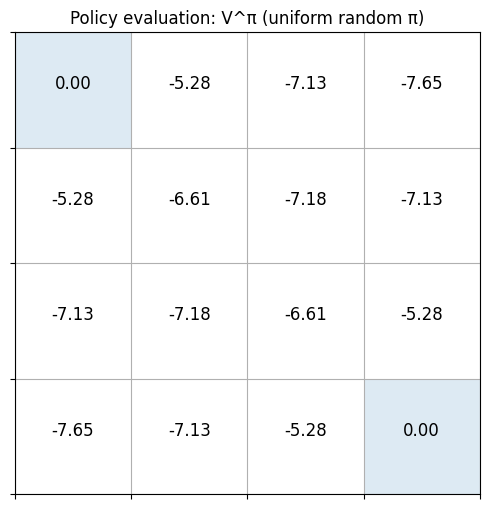

In [6]:
plot_grid(env, V_pi0, policy=None, title="Policy evaluation: V^π (uniform random π)")

## Policy Improvement

Given a value function $(V)$, define a greedy policy:

$\pi'(s) = \arg\max_a \big[r(s,a) + \gamma V(s')\big]$

We'll return:
- `pi_greedy`: a **deterministic** policy (one best action per state)
- `stable`: whether the policy changed (used for stopping policy iteration)

In [7]:
def greedy_action_from_V(env: Gridworld, V: np.ndarray, s: Tuple[int,int], gamma: float) -> str:
    """Helper: return argmax_a [r + gamma V(s')]."""
    best_a = None
    best_q = -np.inf
    for a in ACTIONS:
        ns, r, done = env.step(s, a)
        q = r + gamma * V[ns[0], ns[1]]
        if q > best_q:
            best_q = q
            best_a = a
    return best_a


def policy_improvement(
    env: Gridworld,
    V: np.ndarray,
    old_policy_actions: Optional[Dict[Tuple[int,int], str]] = None,
    gamma: float = 0.9
) -> Tuple[Dict[Tuple[int,int], str], bool]:
    """Greedify policy w.r.t. V. Returns (new_policy_actions, stable)."""
    new_policy_actions: Dict[Tuple[int,int], str] = {}
    stable = True

    for s in env.states():
        if env.is_terminal(s):
            new_policy_actions[s] = "·"
            continue

        # TODO 1:
        # 1) compute the best action using one-step lookpolicy_evaluationahead:
        #       q(s,a) = r(s,a) + gamma * V(s')
        # 2) pick the action with the highest q
        # 3) set stable=False when it changes

        # --- Your Code ---
        # best_a = None
        # best_q = -np.inf
        # for a in ACTIONS:
        #     ns, r, done = env.step(s, a)
        #     q = r + gamma * V[ns[0], ns[1]]
        #     if q > best_q:
        #         best_q = q
        #         best_a = a
        best_a = greedy_action_from_V(env, V, s, gamma)
        new_policy_actions[s] = best_a
        print(f"State {s}: best action = {new_policy_actions[s]}")
        if old_policy_actions is not None:
            if old_policy_actions.get(s, None) != best_a:
                stable = False
        else:
            stable = False
        # -----------------

    print("New policy actions:", new_policy_actions)
    return new_policy_actions, stable

State (0, 1): best action = L
State (0, 2): best action = L
State (0, 3): best action = D
State (1, 0): best action = U
State (1, 1): best action = U
State (1, 2): best action = D
State (1, 3): best action = D
State (2, 0): best action = U
State (2, 1): best action = U
State (2, 2): best action = D
State (2, 3): best action = D
State (3, 0): best action = U
State (3, 1): best action = R
State (3, 2): best action = R
New policy actions: {(0, 0): '·', (0, 1): 'L', (0, 2): 'L', (0, 3): 'D', (1, 0): 'U', (1, 1): 'U', (1, 2): 'D', (1, 3): 'D', (2, 0): 'U', (2, 1): 'U', (2, 2): 'D', (2, 3): 'D', (3, 0): 'U', (3, 1): 'R', (3, 2): 'R', (3, 3): '·'}


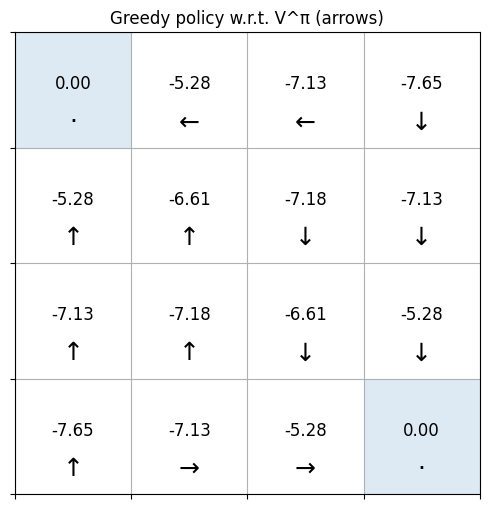

In [8]:
# Greedy policy from V^π (uniform random policy)
pi1_actions, _ = policy_improvement(env, V_pi0, old_policy_actions=None, gamma=gamma)
plot_grid(env, V_pi0, policy=pi1_actions, title="Greedy policy w.r.t. V^π (arrows)")

## Policy Iteration

Repeat until stable:

1) **Policy Evaluation:** compute $(V^\pi)$ for current policy  
2) **Policy Improvement:** greedify to get a better policy

This converges to an optimal policy in finite MDPs.

In [9]:
def policy_iteration(env: Gridworld, gamma: float = 0.9, theta: float = 1e-8, max_outer: int = 100):
    # Start from a random (stochastic) policy, but we will keep a deterministic action-view for stability checks.
    pi_stochastic = uniform_random_policy(env)
    pi_actions = {s: ("·" if env.is_terminal(s) else None) for s in env.states()}

    history = []

    for outer in range(max_outer):
        # 1) Evaluate current (stochastic) policy (inner loop)
        V, iters = policy_evaluation(env, pi_stochastic, gamma=gamma, theta=theta)

        # 2) Improve: produce a deterministic greedy policy
        new_actions, stable = policy_improvement(env, V, old_policy_actions=pi_actions, gamma=gamma)

        history.append((outer, iters, V.copy(), new_actions.copy()))

        # Update policy representation
        pi_actions = new_actions

        # Convert deterministic actions into a stochastic dict π(a|s)
        pi_stochastic = {}
        for s in env.states():
            if env.is_terminal(s):
                pi_stochastic[s] = {a: 0.0 for a in ACTIONS}
            else:
                chosen = pi_actions[s]
                pi_stochastic[s] = {a: (1.0 if a == chosen else 0.0) for a in ACTIONS}

        if stable:
            return V, pi_actions, history

    return V, pi_actions, history

    pi_actions = {s: ("·" if env.is_terminal(s) else None) for s in env.states()}

V_star, pi_star_actions, hist = policy_iteration(env, gamma=gamma)
print("Policy iteration outer loops:", len(hist))
V_star

State (0, 1): best action = L
State (0, 2): best action = L
State (0, 3): best action = D
State (1, 0): best action = U
State (1, 1): best action = U
State (1, 2): best action = D
State (1, 3): best action = D
State (2, 0): best action = U
State (2, 1): best action = U
State (2, 2): best action = D
State (2, 3): best action = D
State (3, 0): best action = U
State (3, 1): best action = R
State (3, 2): best action = R
New policy actions: {(0, 0): '·', (0, 1): 'L', (0, 2): 'L', (0, 3): 'D', (1, 0): 'U', (1, 1): 'U', (1, 2): 'D', (1, 3): 'D', (2, 0): 'U', (2, 1): 'U', (2, 2): 'D', (2, 3): 'D', (3, 0): 'U', (3, 1): 'R', (3, 2): 'R', (3, 3): '·'}
State (0, 1): best action = L
State (0, 2): best action = L
State (0, 3): best action = D
State (1, 0): best action = U
State (1, 1): best action = U
State (1, 2): best action = U
State (1, 3): best action = D
State (2, 0): best action = U
State (2, 1): best action = U
State (2, 2): best action = D
State (2, 3): best action = D
State (3, 0): best ac

array([[ 0.  , -1.  , -1.9 , -2.71],
       [-1.  , -1.9 , -2.71, -1.9 ],
       [-1.9 , -2.71, -1.9 , -1.  ],
       [-2.71, -1.9 , -1.  ,  0.  ]])

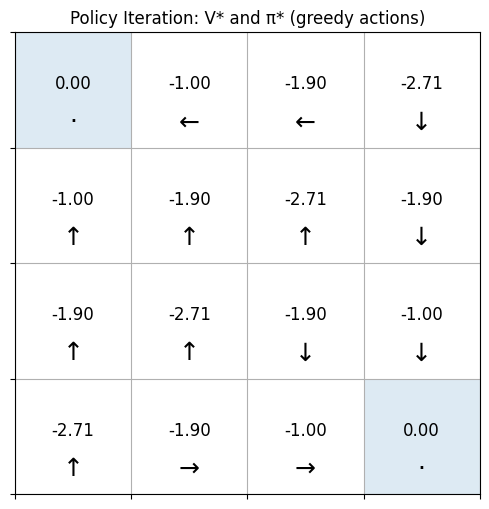

In [10]:
plot_grid(env, V_star, policy=pi_star_actions, title="Policy Iteration: V* and π* (greedy actions)")

In [11]:
pi_star_actions

{(0, 0): '·',
 (0, 1): 'L',
 (0, 2): 'L',
 (0, 3): 'D',
 (1, 0): 'U',
 (1, 1): 'U',
 (1, 2): 'U',
 (1, 3): 'D',
 (2, 0): 'U',
 (2, 1): 'U',
 (2, 2): 'D',
 (2, 3): 'D',
 (3, 0): 'U',
 (3, 1): 'R',
 (3, 2): 'R',
 (3, 3): '·'}

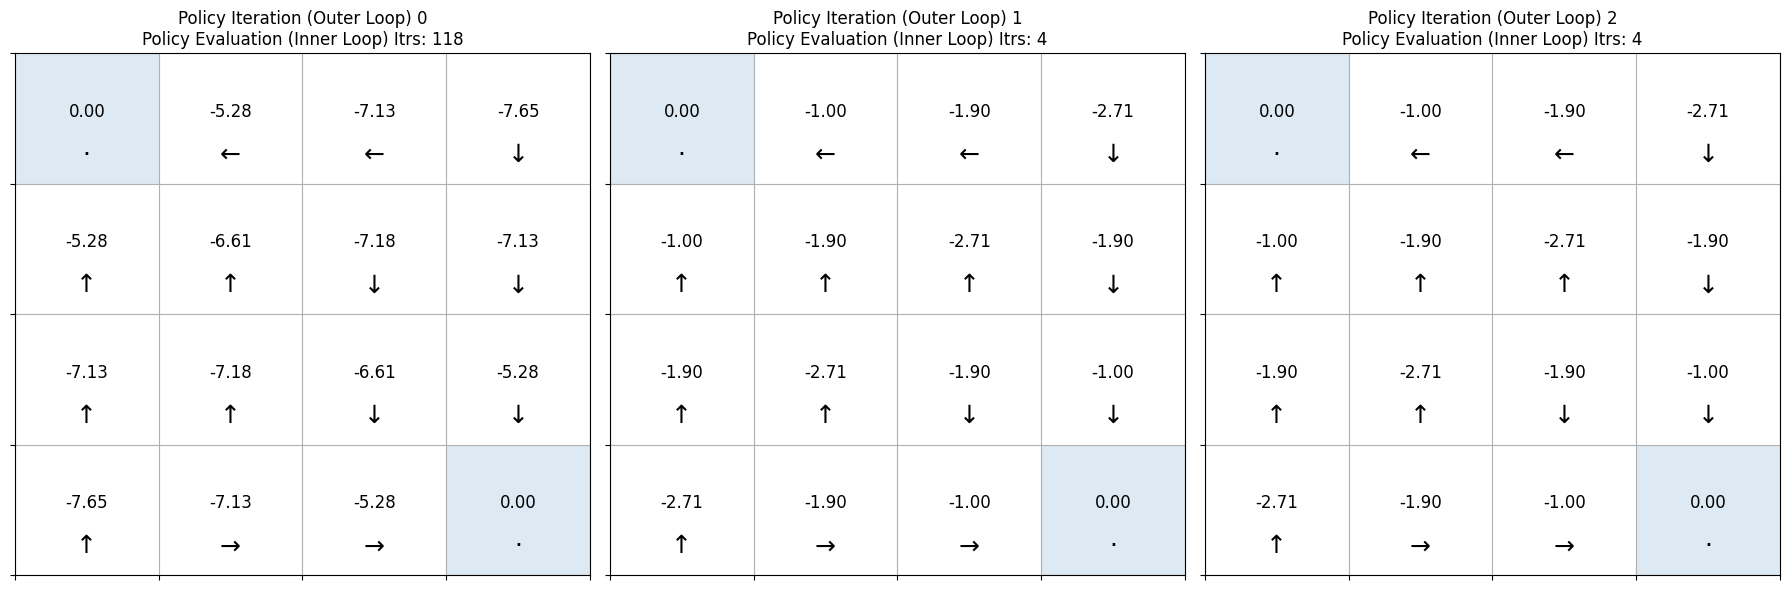

In [12]:
num_plots = len(hist)
fig, axes = plt.subplots(1, num_plots, figsize=(num_plots * 6, 6)) # Adjust figsize for horizontal plots

# Ensure axes is an array even for a single plot
if num_plots == 1:
    axes = [axes]

for i, (outer_iter, pe_iters, V_hist, pi_actions_hist) in enumerate(hist):
    ax = axes[i]
    plot_grid(env, V_hist, policy=pi_actions_hist, title=f"Policy Iteration (Outer Loop) {outer_iter}\nPolicy Evaluation (Inner Loop) Itrs: {pe_iters}", ax=ax)

plt.tight_layout()
plt.show()